In [1]:
from scipy.optimize import minimize
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *
sys.path = original_sys_path

qbt freq at osc 1:	4.32945, 	diff to at osc ground 0.00004, 0.0008% diff
qbt freq at osc 2:	4.32948, 	diff to at osc ground 0.00007, 0.0017% diff
qbt freq at osc 3:	4.32952, 	diff to at osc ground 0.00011, 0.0025% diff
qbt freq at osc 4:	4.32956, 	diff to at osc ground 0.00014, 0.0033% diff
qbt freq at osc 5:	4.32959, 	diff to at osc ground 0.00018, 0.0041% diff
qbt freq at osc 6:	4.32963, 	diff to at osc ground 0.00021, 0.0049% diff
qbt freq at osc 7:	4.32966, 	diff to at osc ground 0.00025, 0.0058% diff
qbt freq at osc 8:	4.32970, 	diff to at osc ground 0.00028, 0.0066% diff
qbt freq at osc 9:	4.32973, 	diff to at osc ground 0.00032, 0.0074% diff
qbt freq at osc 10:	4.32976, 	diff to at osc ground 0.00035, 0.0081% diff
qbt freq at osc 11:	4.32980, 	diff to at osc ground 0.00039, 0.0089% diff
qbt freq at osc 12:	4.32983, 	diff to at osc ground 0.00042, 0.0097% diff
qbt freq at osc 13:	4.32987, 	diff to at osc ground 0.00045, 0.0105% diff
qbt freq at osc 14:	4.32990, 	diff to at osc gr

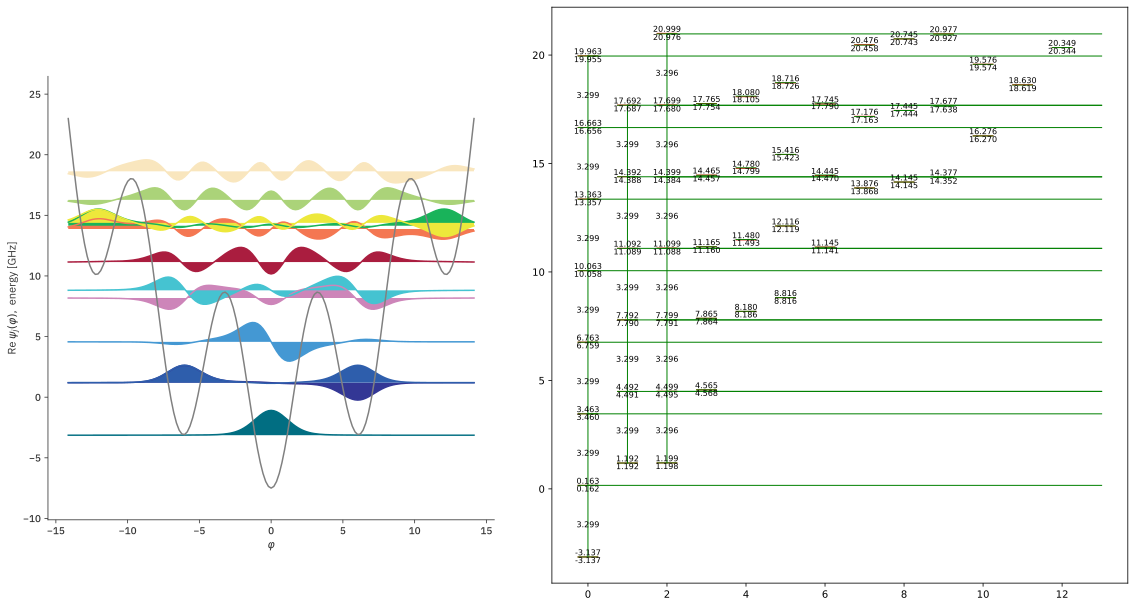

In [2]:
EJ = 7.5
EC = 1.46
EL = 0.23
Er = 3.3
g = 0.1

max_ol = 30
max_ql = 30
system = fluxonium_oscillator_system(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = Er,
    # Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ]
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    ground_freq = dressed_ener(1,0)-dressed_ener(0,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(1,i)-dressed_ener(0,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 2nd state compared to 20-21 (non-linearity): {(dressed_ener(2,i+1)-dressed_ener(2,i))  -(dressed_ener(2,1)-dressed_ener(2,0))}")

    print(f"")
    print(f"00-01: {(dressed_ener(0,1)-dressed_ener(0,0)):.4f}, diff to 20-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 20-01: {abs((dressed_ener(1,1)-dressed_ener(1,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

qbt freq at osc 1:	4.32948, 	diff to at osc ground 0.00005, 0.0012% diff
qbt freq at osc 2:	4.32953, 	diff to at osc ground 0.00010, 0.0024% diff
qbt freq at osc 3:	4.32958, 	diff to at osc ground 0.00015, 0.0036% diff
qbt freq at osc 4:	4.32963, 	diff to at osc ground 0.00021, 0.0047% diff
qbt freq at osc 5:	4.32968, 	diff to at osc ground 0.00026, 0.0059% diff
qbt freq at osc 6:	4.32973, 	diff to at osc ground 0.00031, 0.0070% diff
qbt freq at osc 7:	4.32978, 	diff to at osc ground 0.00035, 0.0082% diff
qbt freq at osc 8:	4.32983, 	diff to at osc ground 0.00040, 0.0093% diff
qbt freq at osc 9:	4.32988, 	diff to at osc ground 0.00045, 0.0104% diff
qbt freq at osc 10:	4.32992, 	diff to at osc ground 0.00050, 0.0116% diff
qbt freq at osc 11:	4.32997, 	diff to at osc ground 0.00055, 0.0127% diff
qbt freq at osc 12:	4.33002, 	diff to at osc ground 0.00060, 0.0138% diff
qbt freq at osc 13:	4.33007, 	diff to at osc ground 0.00064, 0.0149% diff
qbt freq at osc 14:	4.33011, 	diff to at osc gr

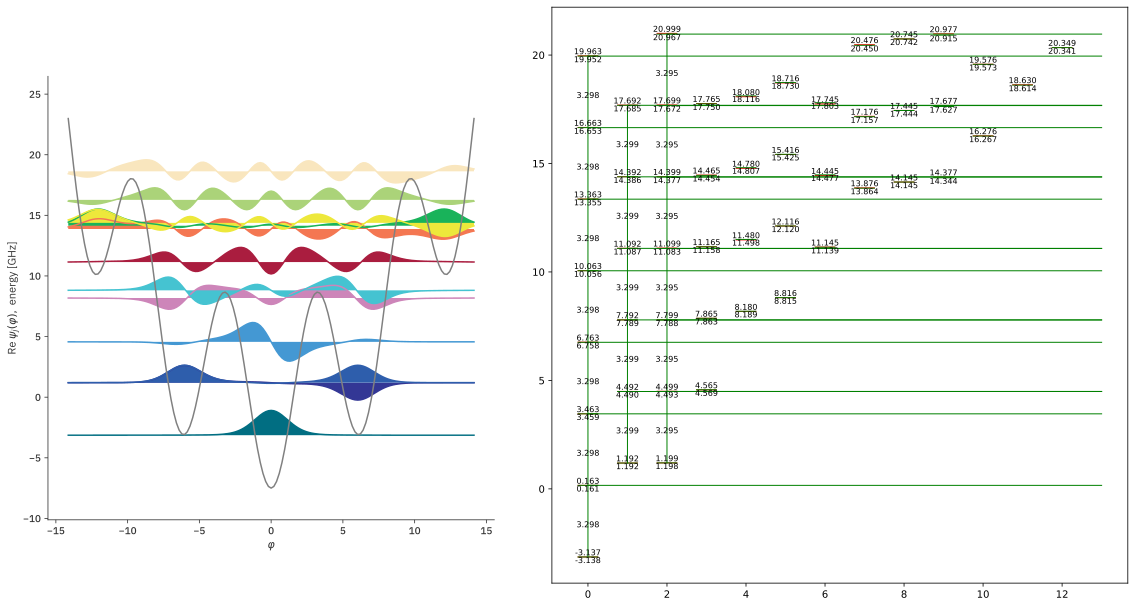

In [5]:
EJ = 7.5
EC = 1.46
EL = 0.23
Er = 3.3
g = 0.12

max_ol = 30
max_ql = 30
system = fluxonium_oscillator_system(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = Er,
    # Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ]
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    ground_freq = dressed_ener(1,0)-dressed_ener(0,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(1,i)-dressed_ener(0,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 2nd state compared to 20-21 (non-linearity): {(dressed_ener(2,i+1)-dressed_ener(2,i))  -(dressed_ener(2,1)-dressed_ener(2,0))}")

    print(f"")
    print(f"00-01: {(dressed_ener(0,1)-dressed_ener(0,0)):.4f}, diff to 20-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 20-01: {abs((dressed_ener(1,1)-dressed_ener(1,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

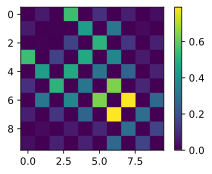

In [78]:
import scqubits

n_evals = 10
qbt = scqubits.Fluxonium(EJ = 6.86,EC = 1.46,EL = 0.23, cutoff = 110,flux = 0)
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)

import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=((3+3/8), (3+3/8)*0.75))
plt.imshow(abs(elements), cmap='viridis', interpolation='nearest')
plt.colorbar()
# plt.title("Fluxonium Charge Operator Matrix Heatmap")
# plt.xlabel("i")
# plt.ylabel("j")

plt.tight_layout()
plt.savefig('fig03matrix_elements_vlad_qubit.pdf', format='pdf', bbox_inches='tight')
plt.show()
